In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data = pd.read_csv(r"C:\Python\Customer Segmentation\Data\customer_segmentation.csv")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [4]:
data.shape

(2240, 29)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df = data.copy()
df.shape

(2240, 29)

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(2216, 29)

In [10]:
df.select_dtypes(exclude='object').describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
## Converting Date from object to Datatime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [12]:
df['Dt_Customer'].dtype

dtype('<M8[ns]')

In [13]:
## Creating new feature Age
df['Age'] = 2026 - df['Year_Birth']

In [14]:
## Creating new feature as Total no. of Childreans
df['Total_Childrens'] = df['Kidhome'] + df['Teenhome']

In [15]:
## Creating new feature as Total Spending
df['Total_Spending'] = df[['MntWines', 'MntFruits',
                           'MntMeatProducts', 'MntFishProducts', 
                           'MntSweetProducts','MntGoldProds']].sum(axis=1)

In [16]:
## Creating new feature for Customer Tenure
df['Customer_Since'] = (pd.Timestamp('2026-09-09') - df['Dt_Customer']).dt.days

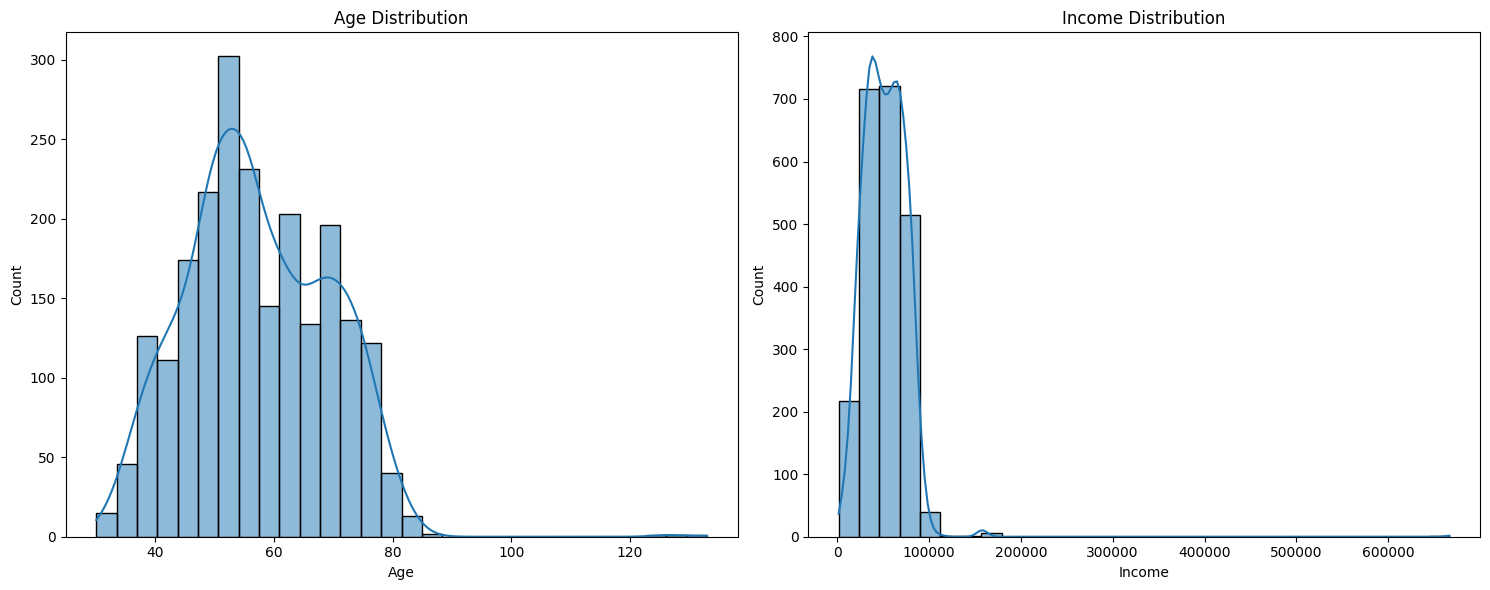

In [17]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Age Distribution")

sns.histplot(df['Income'], bins=30, kde=True, ax=ax[1])
ax[1].set_title("Income Distribution")

plt.tight_layout()
plt.show()

In [18]:
print('Skewness:')
print(f"Age: {df['Age'].skew() :.4f}")
print(f"Income: {df['Income'].skew() :.4f}")

Skewness:
Age: 0.3537
Income: 6.7635


- `Income` is higly rightly skewed. We should apply log(1+x) transformation to Income. 

In [19]:
print("Variation(S.D.)")
print(f"Age: {df['Age'].std() :.4f}")
print(f"Income: {df['Income'].std() :.4f}")

Variation(S.D.)
Age: 11.9856
Income: 25173.0767


In [20]:
df[(df['Age'] >= 40) & (df['Age'] <= 60)].shape

(1221, 33)

In [21]:
(1221/2216)*100

55.099277978339344

- **55%** of customers are from age group **40-60** years old. We can create a new feature **AgeGroup** based on this.

In [22]:
print("Age-Group Distribution")
print(f"<40: {(df[df['Age'] < 40].shape[0] / df.shape[0])*100 :.4f}")
print(f"40-60: {(df[(df['Age'] >= 40) & (df['Age'] <= 60)].shape[0] / df.shape[0])*100 :.4f}")
print(f">60: {(df[df['Age'] > 60].shape[0] / df.shape[0])*100 :.4f}")

Age-Group Distribution
<40: 6.5884
40-60: 55.0993
>60: 38.3123


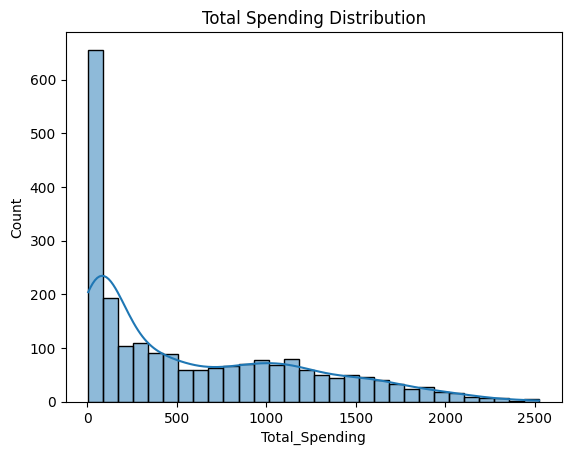

In [23]:
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

In [24]:
print(f"skewness: {df['Total_Spending'].skew():.4f}")

skewness: 0.8581


- Total spending is also hightly skewed. We need to rescale 'Total spending' to reduce skewness.

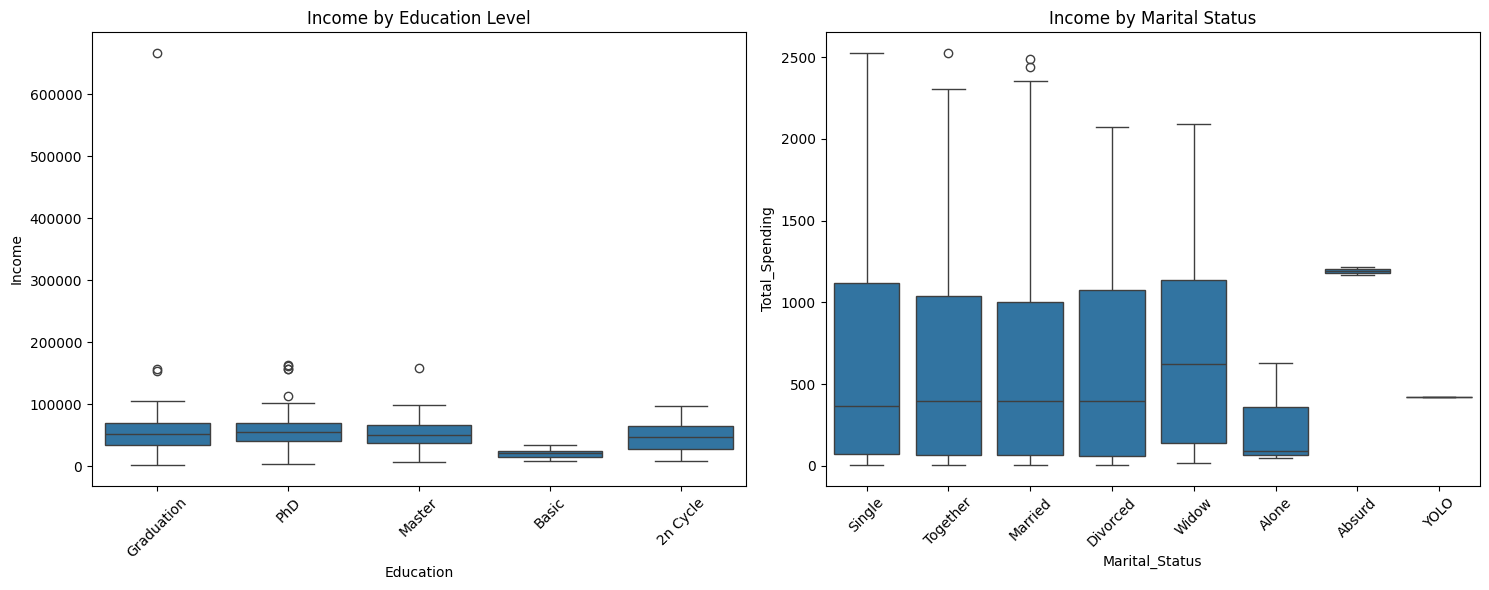

In [25]:
fig,ax = plt.subplots(1,2, figsize=(15,6))

sns.boxplot(x='Education', y='Income', data=df, ax=ax[0])
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Income by Education Level")

sns.boxplot(x='Marital_Status', y='Total_Spending', data=df, ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Income by Marital Status")

plt.tight_layout()
plt.show()

- The **income distributions of Graduate and PhD customers are relatively similar**, with a few outliers in both groups. One **extreme outlier** is also present and may indicate a potential data-entry issue that should be investigated.

- The **median income across Single, Together, Married, and Divorced customers is relatively similar**. However, some outliers are present, particularly among **Together and Married** customers.

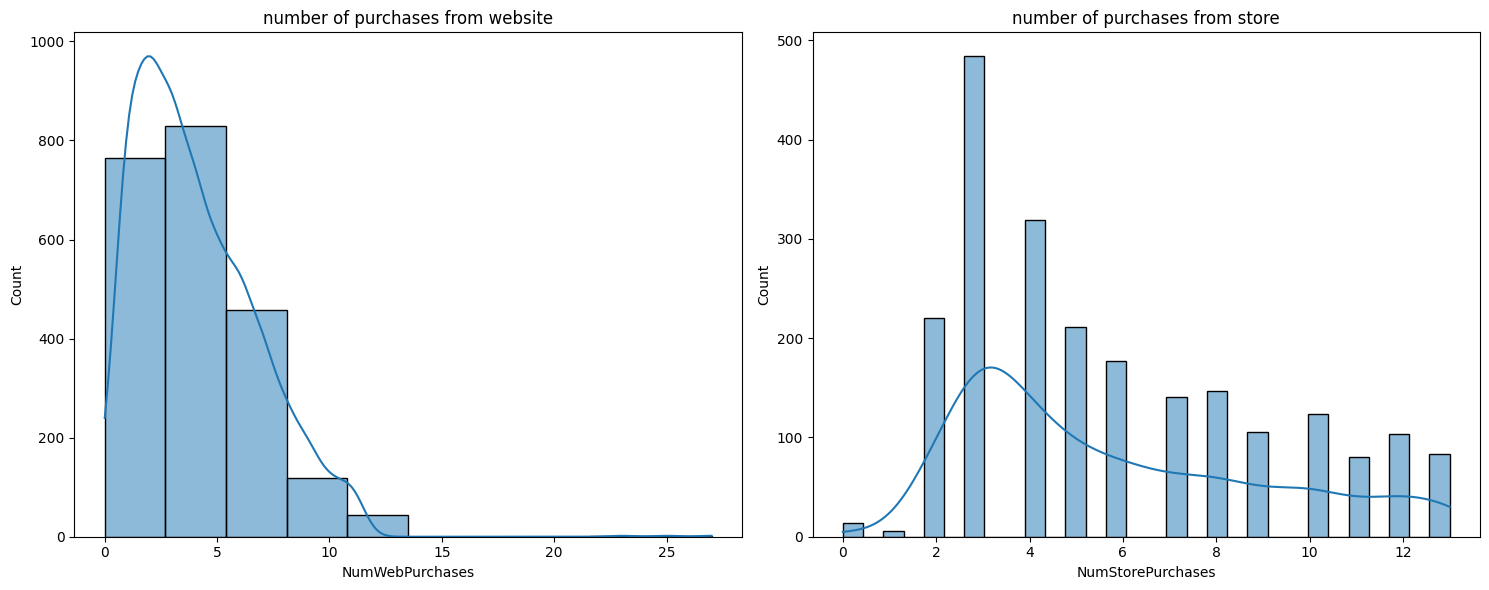

In [26]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['NumWebPurchases'], bins=10, kde=True, ax=ax[0])
ax[0].set_title("number of purchases from website")

sns.histplot(df['NumStorePurchases'], bins=30, kde=True, ax=ax[1])
ax[1].set_title("number of purchases from store")

plt.tight_layout()
plt.show()

- `NumWebPurchases` is **highly right-skewed**, with the majority of customers making between **0 and 5 web purchases** and relatively few customers making a larger number of purchases.

- `NumStorePurchases` is concentrated around lower purchase frequencies, with **2 purchases being the most common**, followed by **4 purchases**.

In [27]:
print('Skewness:')
print(f"NumWebPurchases: {df['NumWebPurchases'].skew() :.4f}")
print(f"NumStorePurchases: {df['NumStorePurchases'].skew() :.4f}")

Skewness:
NumWebPurchases: 1.1970
NumStorePurchases: 0.7018


- `NumWebPurchases` is **highly skewed**, we have to apply transformation to reduce skewness. Also `NumStorePurchases` is moderately skewed.

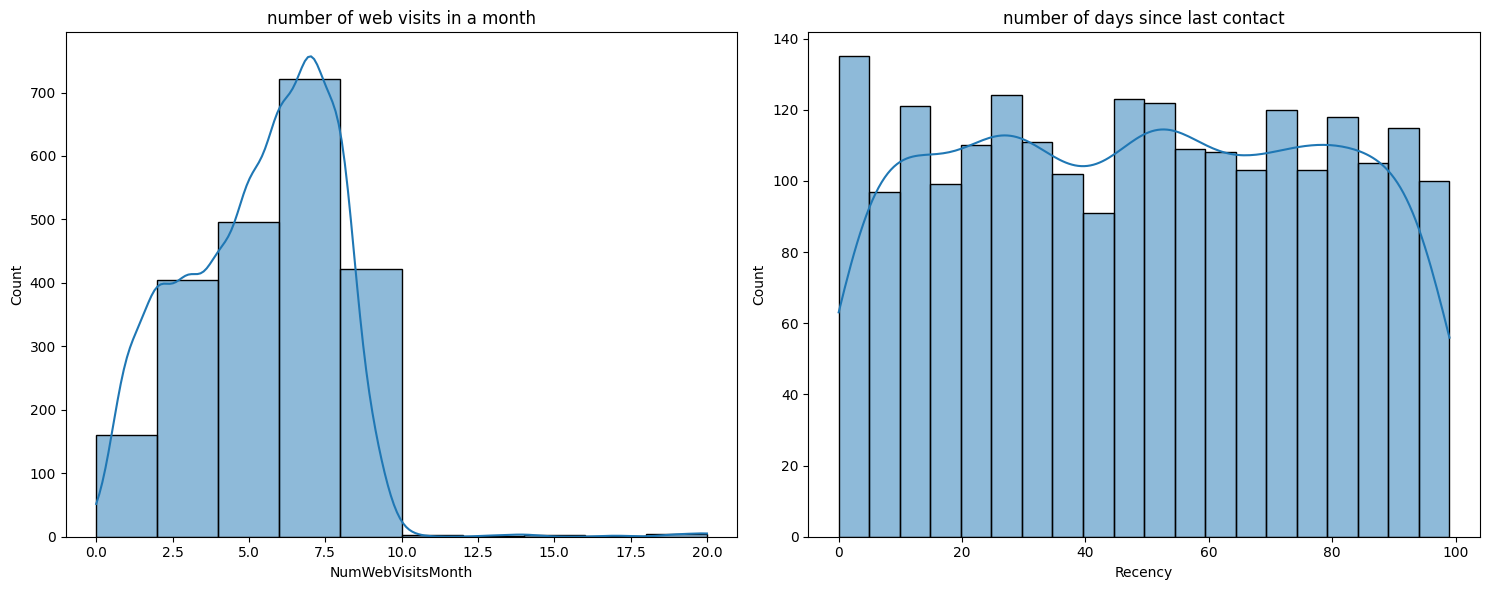

In [28]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

sns.histplot(df['NumWebVisitsMonth'], bins=10, kde=True, ax=ax[0])
ax[0].set_title("number of web visits in a month")

sns.histplot(df['Recency'], bins=20, kde=True, ax=ax[1])
ax[1].set_title("number of days since last contact")

plt.tight_layout()
plt.show()

In [29]:
print('Skewness:')
print(f"NumWebVisitsMonth: {df['NumWebVisitsMonth'].skew() :.4f}")
print(f"Recency: {df['Recency'].skew() :.4f}")

Skewness:
NumWebVisitsMonth: 0.2180
Recency: 0.0016


In [30]:
corr = df[['Income', 'Recency', 'Age', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases']].corr()

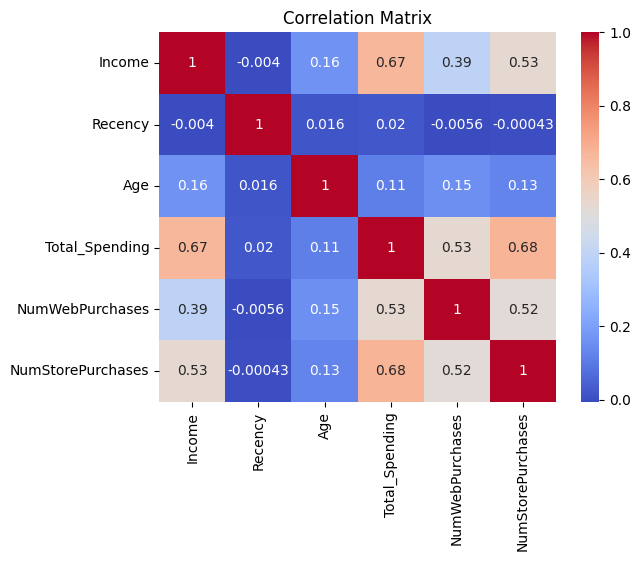

In [31]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [32]:
group_1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)
group_1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

In [33]:
group_2 = df.groupby('Education')['Income'].mean().sort_values(ascending=False)
group_2

Education
PhD           56145.313929
Master        52917.534247
Graduation    52720.373656
2n Cycle      47633.190000
Basic         20306.259259
Name: Income, dtype: float64

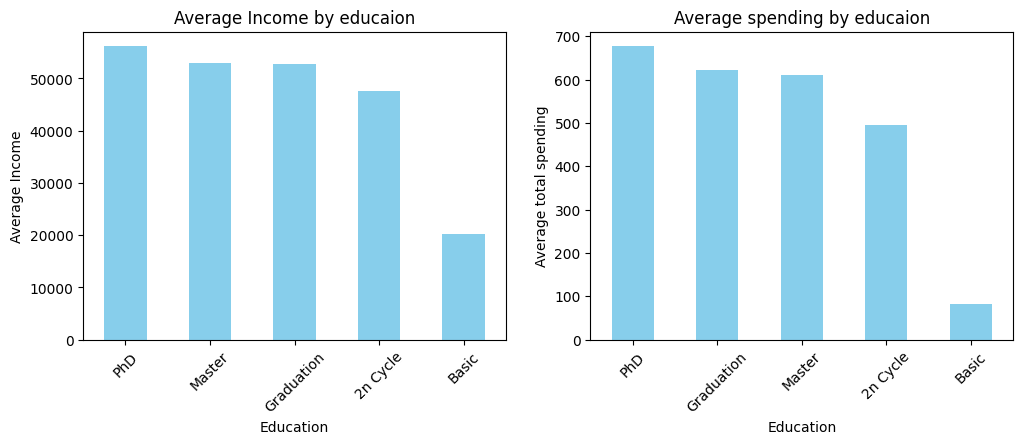

In [52]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

group_2.plot(kind='bar', color='skyblue', ax=ax[0])
ax[0].set_title('Average Income by educaion')
ax[0].set_ylabel('Average Income')
ax[0].tick_params(axis='x', rotation=45)

group_1.plot(kind='bar', color='skyblue', ax=ax[1])
ax[1].set_title('Average spending by educaion')
ax[1].set_ylabel('Average total spending')
ax[1].tick_params(axis='x', rotation=45)
plt.show()

- We can observe that customers having higher education tend to sepend more than those with basic and 2n cycle eduction. This features also have moderate correlation(~0.67) with each other.

In [40]:
## Creating new feature based on whether customer accepted any campaign
df['AcceptedCampaigns'] = df[['AcceptedCmp3', 'AcceptedCmp4', 
                        'AcceptedCmp5', 'AcceptedCmp1',
                        'AcceptedCmp2', 'Response']].sum(axis=1)

In [41]:
## Creating new feature based on whether customer accepted any campaign
df['AcceptedAny'] = df['AcceptedCampaigns'].apply(lambda x:1 if x>0 else 0)

In [43]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']

In [44]:
## Creating new feature as Age group
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [46]:
group_3 = df.groupby('AgeGroup')['Income'].mean().round(2)
group_3

AgeGroup
18-29    10960.50
30-39    47905.48
40-49    48057.59
50-59    50479.32
60-69    55980.03
70+      58767.08
Name: Income, dtype: float64

In [51]:
group_4 = df.groupby('AgeGroup')['Total_Spending'].mean().round(2)
group_4

AgeGroup
18-29     69.00
30-39    651.77
40-49    500.46
50-59    552.66
60-69    676.23
70+      744.38
Name: Total_Spending, dtype: float64

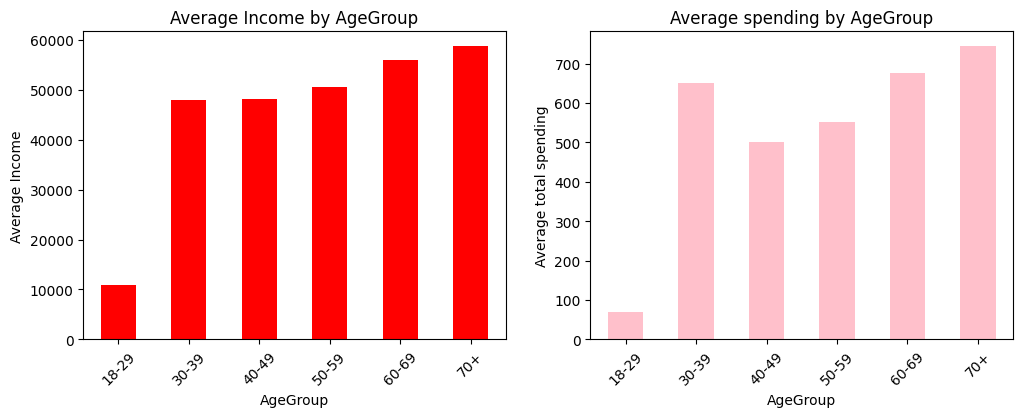

In [53]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

group_3.plot(kind='bar', color='red', ax=ax[0])
ax[0].set_title('Average Income by AgeGroup')
ax[0].set_ylabel('Average Income')
ax[0].tick_params(axis='x', rotation=45)

group_4.plot(kind='bar', color='pink', ax=ax[1])
ax[1].set_title('Average spending by AgeGroup')
ax[1].set_ylabel('Average total spending')
ax[1].tick_params(axis='x', rotation=45)
plt.show()

- **Average income increases substantially with age**. The 18–29 age group has the lowest average income, while customers aged 60–69 and 70+ have the highest average income.

- In terms of total spending, the 18–29 age group has by far the lowest average spending. Spending increases for the 30–39 group, decreases for the 40–49 and 50–59 groups and increases again among customers aged 60–69 and 70+.

- Interestingly, although the average income of customers aged **30–39, 40–49, and 50–59 is relatively similar**, the 30–39 group has considerably higher average spending than the 40–49 and 50–59 groups. This suggests that income alone may not explain differences in spending behavior across age groups.

- The relatively high income and spending observed among the 70+ group may be influenced by outliers or the relatively small sample size of this age group.

### Clustering

In [54]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']
X = df[features].copy()

In [55]:
X.shape[0]

2216

In [56]:
outlier_summary = {'features': [], 'lower_bound': [], 'upper_bound': [], 'outliers': [], 'outliers_percentage': []}
for feature in X.columns:
    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR*1.5
    upper_bound = Q3 + IQR*1.5

    outlier = X[(X[feature] < lower_bound) | (X[feature] > upper_bound)]

    outlier_percentage = (len(outlier)/X.shape[0])*100

    outlier_summary['features'].append(feature)
    outlier_summary['lower_bound'].append(lower_bound)
    outlier_summary['upper_bound'].append(upper_bound)
    outlier_summary['outliers'].append(len(outlier))
    outlier_summary['outliers_percentage'].append(round(outlier_percentage, 2))
    

In [57]:
outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,features,lower_bound,upper_bound,outliers,outliers_percentage
0,Age,22.0,94.0,3,0.14
1,Income,-14525.5,118350.5,8,0.36
2,Total_Spending,-1399.5,2516.5,3,0.14
3,NumWebPurchases,-4.0,12.0,3,0.14
4,NumStorePurchases,-4.5,15.5,0,0.00
5,NumWebVisitsMonth,-3.0,13.0,8,0.36
6,Recency,-51.0,149.0,0,0.00


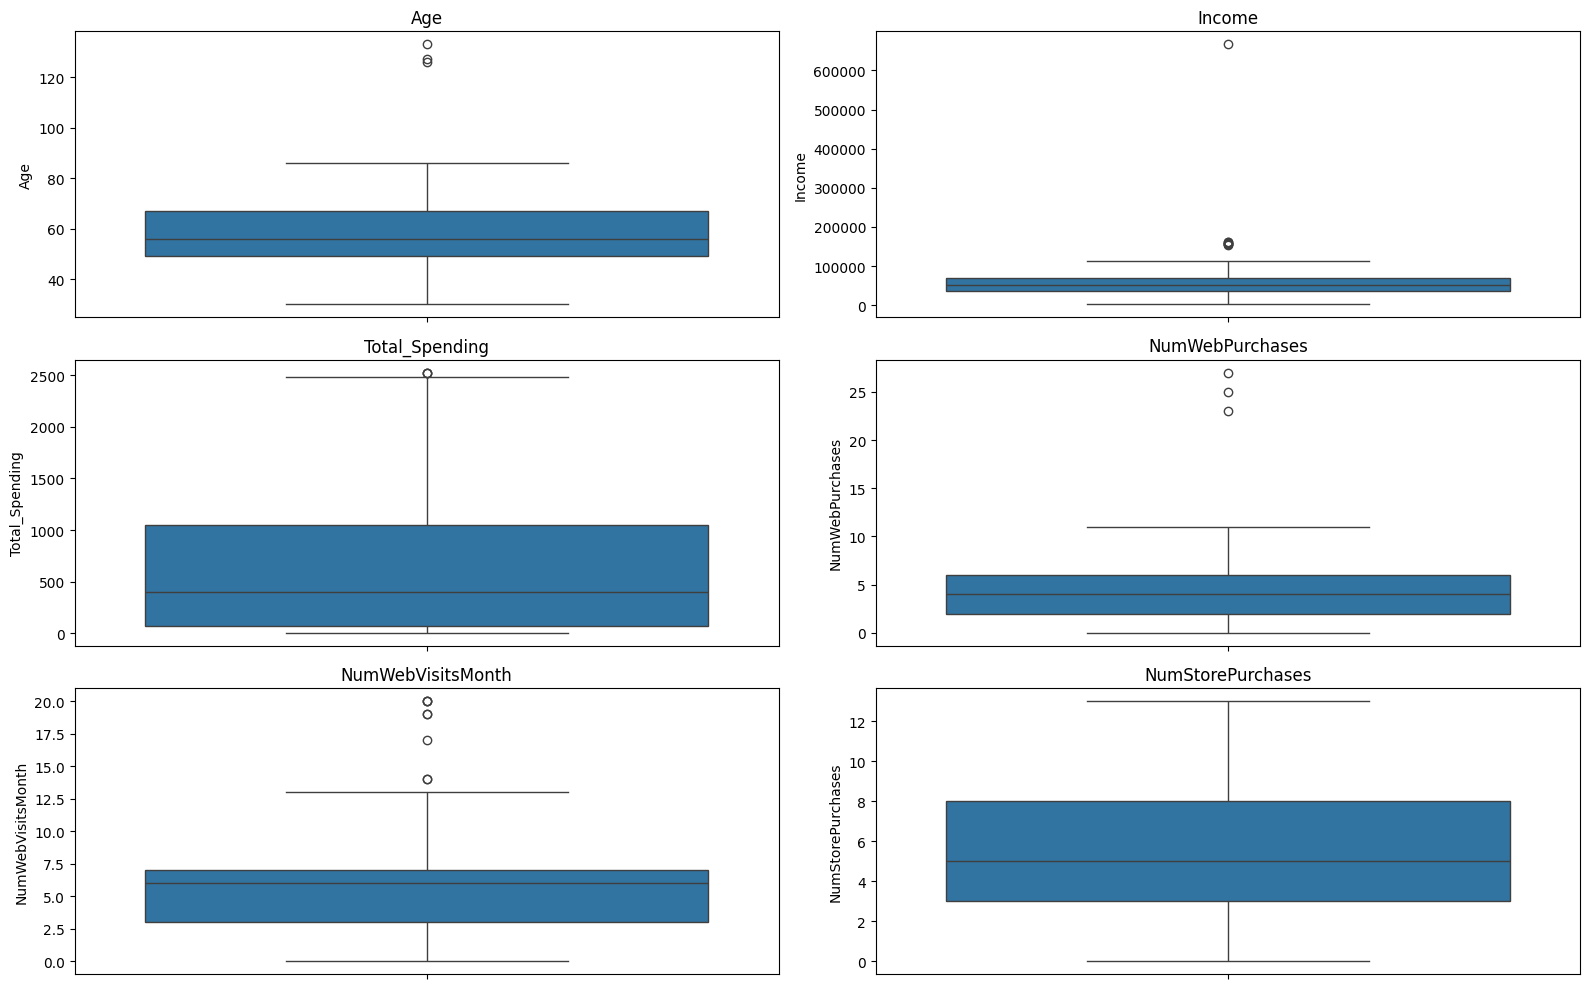

In [58]:
columns = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumWebVisitsMonth', 'NumStorePurchases']
fig,ax = plt.subplots(3,2, figsize=(16,10))
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(df[col], ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [59]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [60]:
X_scaled = scalar.fit_transform(X)

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from kneed import KneeLocator

In [62]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [63]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++', verbose=False)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

  File "c:\Users\theis\.conda\envs\segmentenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\theis\.conda\envs\segmentenv\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\theis\.conda\envs\segmentenv\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\theis\.conda\envs\segmentenv\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [64]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,10218.620144,0.321512,1.287115
3,9007.752707,0.264457,1.669448
4,8158.828480,0.194680,1.752531
5,7567.271348,0.191735,1.746601
6,7008.848496,0.192706,1.460196
7,6574.781207,0.182812,1.403099
8,6155.304235,0.185824,1.453153
9,5852.568266,0.186141,1.386952


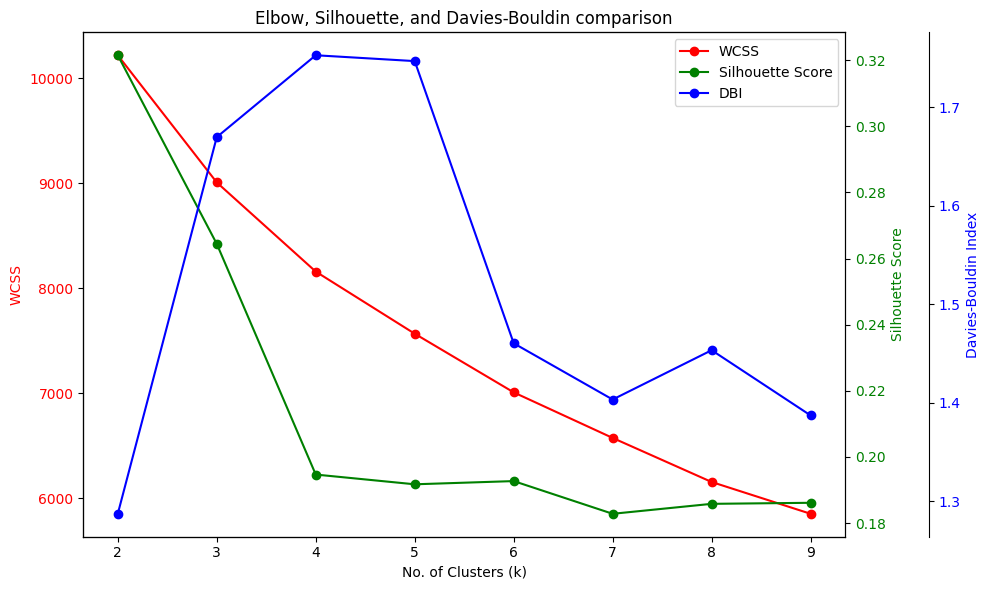

In [65]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

- WCSS (red): Decreases smoothly across all k, no clear elbow bend.
- Silhouette (green): Peaks at k=2 (~0.32), drops sharply and stays low (~0.18–0.19) from k=4 through k=8.
- DBI (blue): Best (lowest) at k=2 (~1.28), worst (highest) at k=4 (~1.73), gradually improves again toward k=8–9.

In [67]:
K = range(2,10)
knee = KneeLocator(K,
                   wcss,
                   curve='convex',
                   direction='decreasing')

print('Optimal_K:', knee.elbow)

Optimal_K: 4


In [68]:
kmeans = KMeans(n_clusters=4)
df['Cluster'] = kmeans.fit_predict(X_scaled)

- **k=4**, despite looking plausible on the WCSS curve, is actually near the **worst point for both silhouette and DBI** (*separation is weakest there, not strongest*).
- No k shows consistent agreement across all three metrics. 

### Likely causes
1. correlated/redundant features
2. high dimensionality relative to sample size after one-hot encoding
3. skewed distributions.

In [69]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
X = df[features].copy()

In [70]:
X['Income'] = X['Income'].astype('int64')

In [71]:
X['Income'] = np.log1p(X['Income'])
X['NumWebPurchases'] = np.log1p(X['NumWebPurchases'])
X['Total_Spending'] = np.log1p(X['Total_Spending'])
X['NumStorePurchases'] = np.sqrt(X['NumStorePurchases'])

In [72]:
for feature in ['Income', 'NumWebPurchases', 'Total_Spending', 'NumStorePurchases']:
    print(f"{feature}: {X[feature].skew():.4f}")

Income: -1.1680
NumWebPurchases: -0.2789
Total_Spending: -0.3728
NumStorePurchases: 0.1571


In [73]:
X['Income'] = np.expm1(X['Income'])
X['Total_Spending'] = np.expm1(X['Total_Spending'])

- Since applying the **log(1+x) transformation did not substantially reduce the skewness**, we applied the **Yeo-Johnson transformation** as an alternative approach to improve the distribution's symmetry.

In [74]:
from sklearn.preprocessing import PowerTransformer
yeo_john = PowerTransformer(method='yeo-johnson')

In [75]:
X['Income'] = X['Income'].astype('int64')

In [76]:
X[['Income', 'Total_Spending']] = yeo_john.fit_transform(X[['Income', 'Total_Spending']])

In [77]:
for feature in ['Income',  'Total_Spending']:
    print(f"{feature}: {X[feature].skew():.4f}")

Income: 0.2270
Total_Spending: -0.1207


In [78]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [79]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

In [80]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,7302.792166,0.397445,1.004665
3,6124.041019,0.298556,1.376605
4,5480.532489,0.290342,1.295785
5,4867.797794,0.235239,1.405315
6,4507.016343,0.223780,1.388518
7,4235.189898,0.216926,1.368112
8,4014.800254,0.215573,1.397032
9,3772.689222,0.222070,1.295824


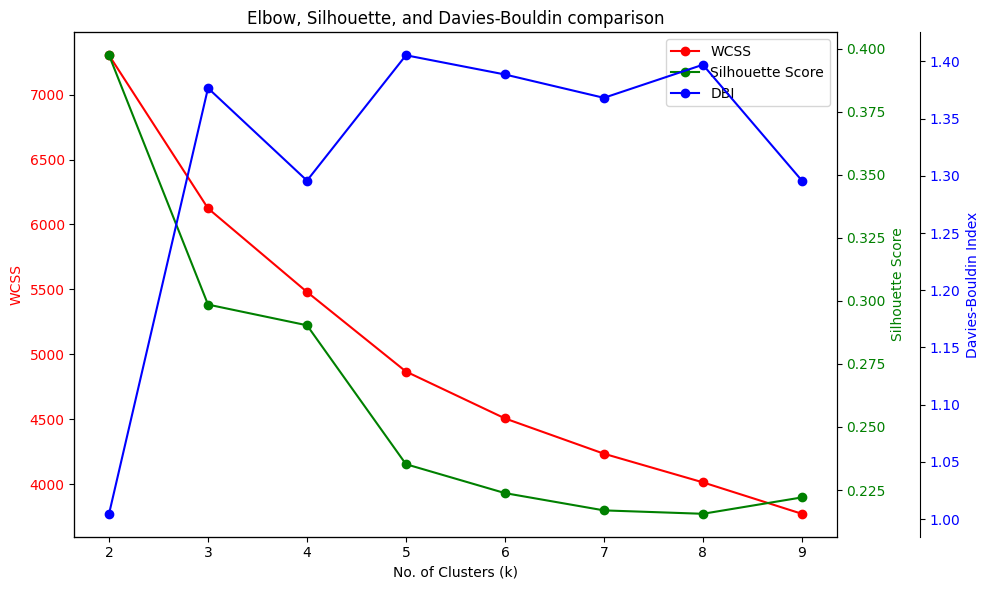

In [81]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

In [ ]:
K = range(2,10)
knee = KneeLocator(K,
                   wcss,
                   curve='convex',
                   direction='decreasing')

print('Optimal_K:', knee.elbow)

Optimal_K: 5


- Skew correction improved one metric's stability (silhouette) but didn't resolve the core issue.
- DBI's behavior around k=5 and k=8 suggests there's still something distorting separation at that specific point and more broadly, no k in the 3–9 range shows strong, corroborated cluster structure.

### Likely cause
1. correlated features 

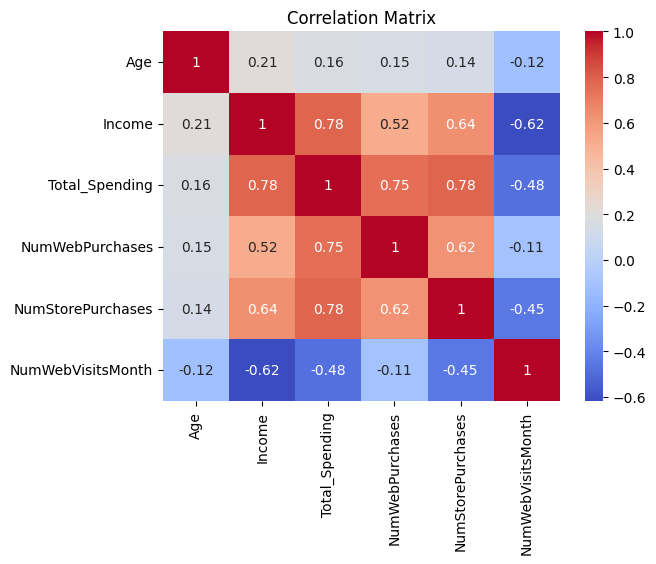

In [83]:
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- `Total_Spending` has moderate to high correlation to all features. We will `Total_Spending` and see whether results will improve or not.

In [84]:
X.drop('Total_Spending', axis=1, inplace=True)

In [85]:
X_scaled = scalar.fit_transform(X)

In [86]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

In [87]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,6755.231740,0.354288,1.130416
3,5646.717268,0.284985,1.391274
4,4989.227310,0.280971,1.271920
5,4411.191865,0.241391,1.353585
6,4106.994076,0.223488,1.305684
7,3838.887017,0.221467,1.307550
8,3617.712068,0.221331,1.331813
9,3448.778188,0.210252,1.349678


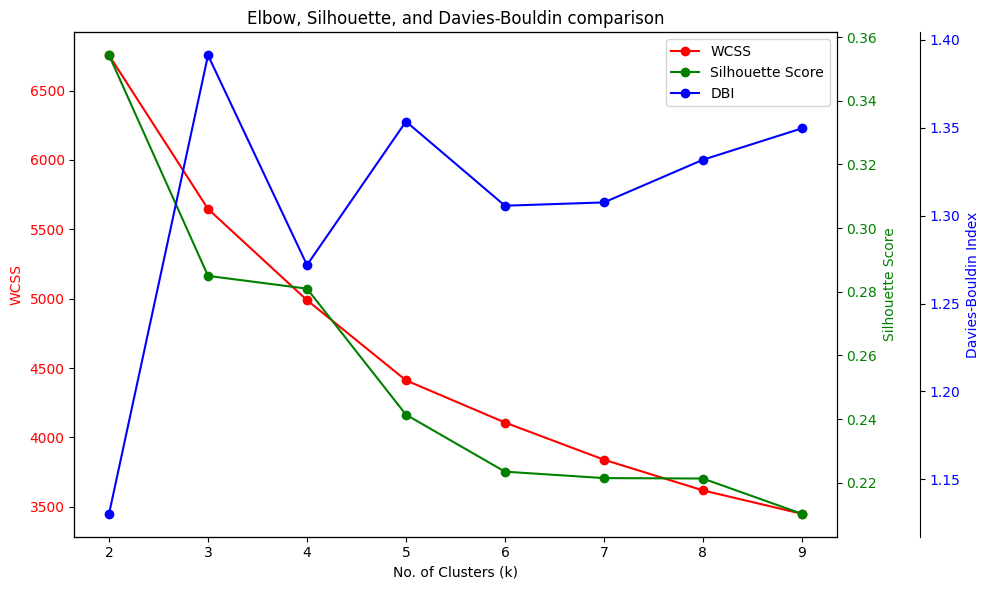

In [88]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

- WCSS(red): decreases continuously as the number of clusters increases. After k=5-6 improvement becomes smaller.
- Silhouette (green): The score is highest at k = 2 (~0.35) and generally decreases as the number of clusters increases. This indicates that the cluster separation and cohesion are strongest at k = 2 among the tested values.
- DBI(blue): The lowest DBI occurs at k = 2 (~1.17), while k = 3 has the highest value. After k = 4, the DBI fluctuates but remains higher than at k = 2.

In [89]:
K = range(2,10)
knee = KneeLocator(K,
                   wcss,
                   curve='convex',
                   direction='decreasing')

print('Optimal_K:', knee.elbow)

Optimal_K: 5


### Hierarchial Clustering

In [102]:
import scipy.cluster.hierarchy as hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, fcluster
from scipy.spatial.distance import pdist

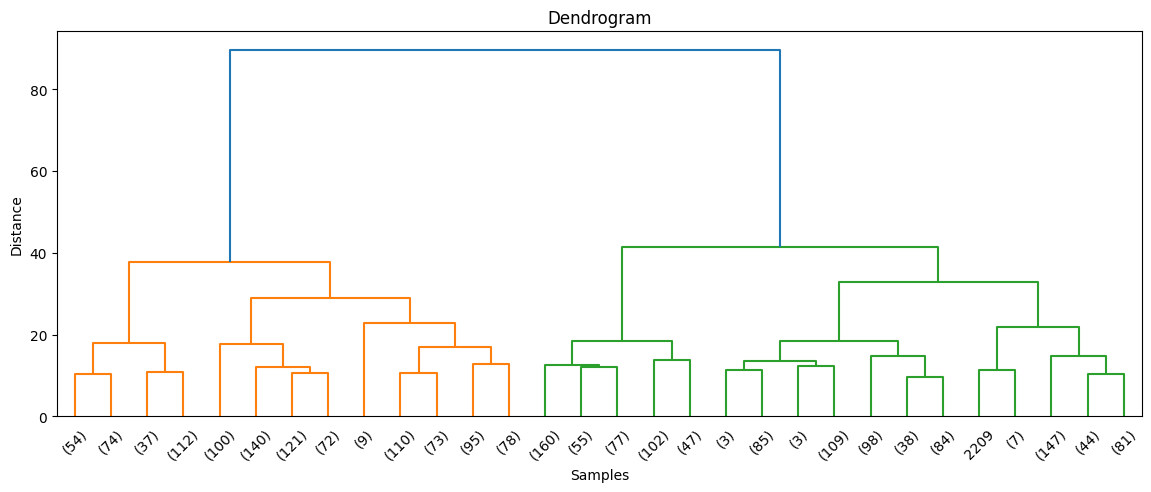

In [91]:
## ward linkage
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30)  # truncate for readability with many samples
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [93]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenetic correlation: {coph_corr:.4f}")

cophenetic correlation: 0.5417


- Since **cophenetic correlation <0.6** indicate dendrogram distorts the actual distance relationships.

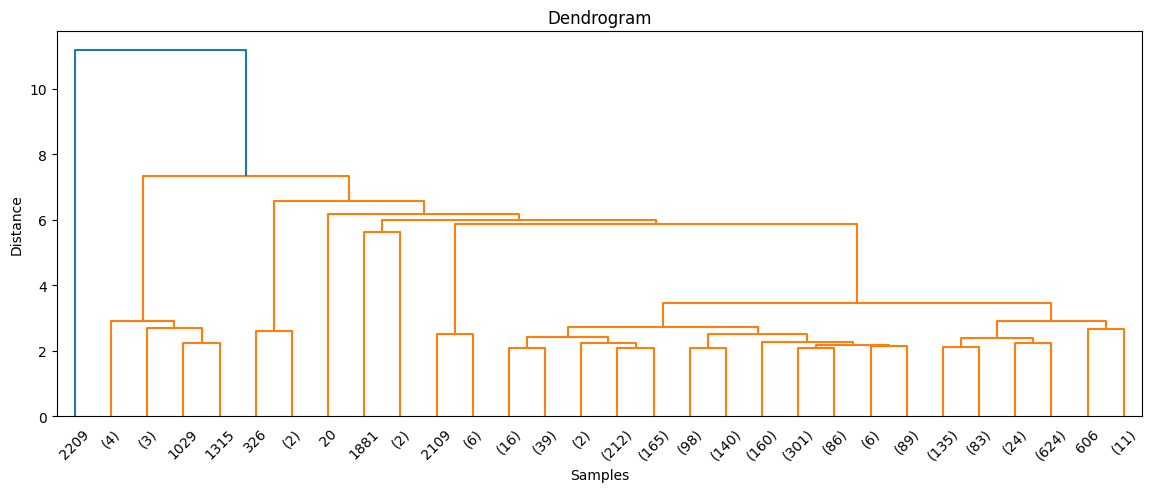

In [94]:
## Average Linkage
Z = linkage(X_scaled, method='average')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [95]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenetic correlation: {coph_corr:.4f}")

cophenetic correlation: 0.7390


- Moderate **cophenetic correlation(~0.74)**.

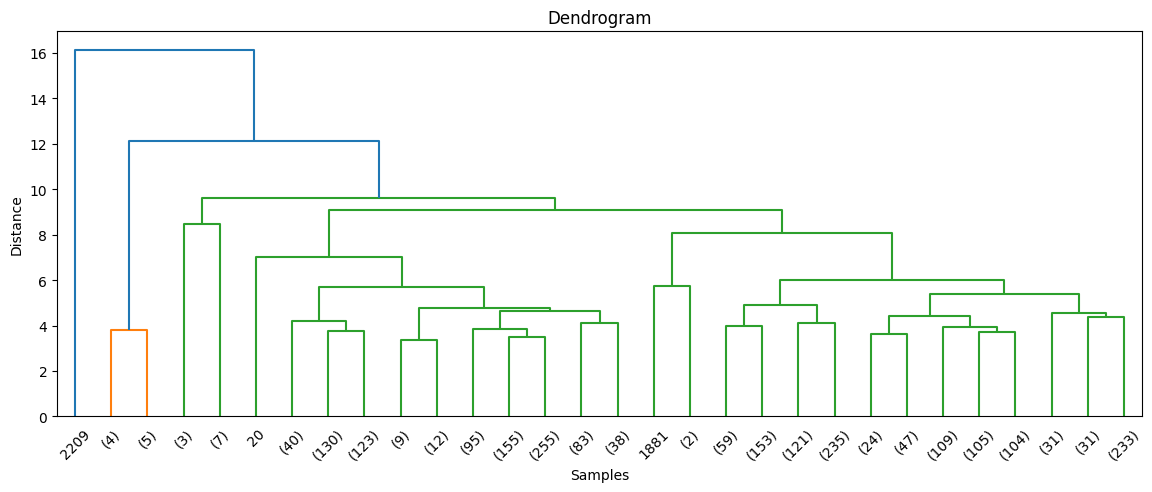

In [96]:
## complete linkage
Z = linkage(X_scaled, method='complete')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [97]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenet correlation: {coph_corr:.4f}")

cophenet correlation: 0.6429


- Moderate **cophenetic correlation(~0.64)**.

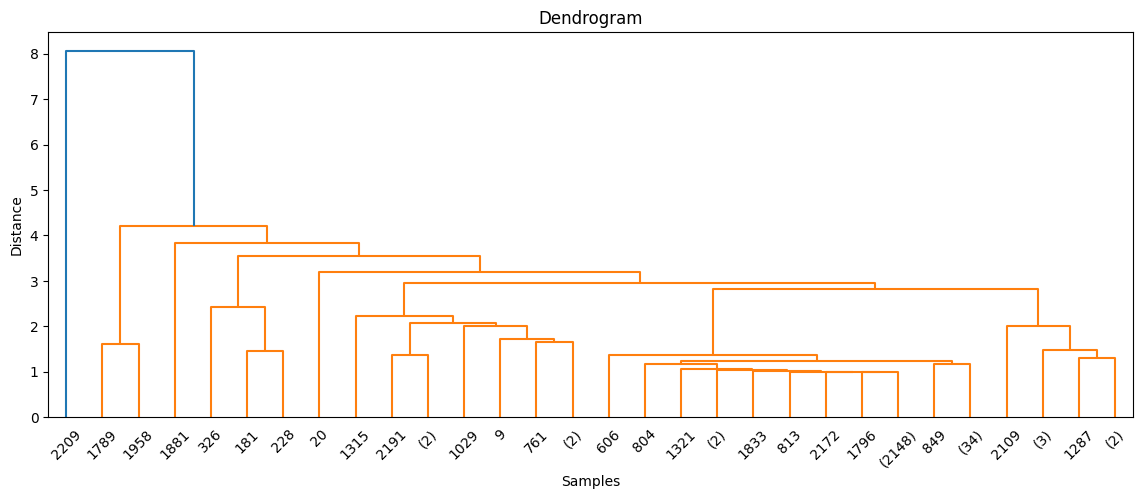

In [98]:
## single linkage
Z = linkage(X_scaled, method='single')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [99]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenet correlation: {coph_corr:.4f}")

cophenet correlation: 0.5380


- Since **cophenetic correlation <0.6** indicate dendrogram distorts the actual distance relationships. 

In [100]:
coph_corr_df = pd.DataFrame({'cophenet_corr': [0.5380, 0.6429, 0.7390, 0.5417]}, index=['single', 'complete', 'average', 'ward'])
coph_corr_df

,cophenet_corr
single,0.5380
complete,0.6429
average,0.7390
ward,0.5417


- **Average linkage** is clearly the best fit for data's actual distance structure, landing in the **"moderate, usable"** range (0.6–0.75).

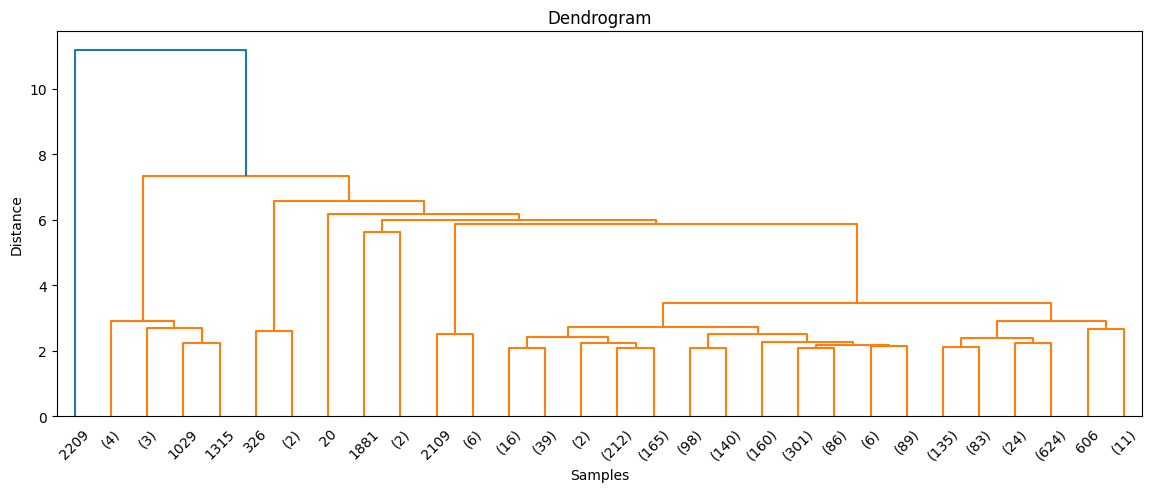

In [101]:
Z = linkage(X_scaled, method='average')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [103]:
silhoutte_scores = []
dbi_scores = []
Z = linkage(X_scaled, method='average')
for k in range(2,10):
    labels = fcluster(Z, k, criterion='maxclust')
    silhoutte_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

evaluation_metrics = pd.DataFrame({'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,Silhouetter Scores,DBI
2,0.739094,0.190748
3,0.594823,0.425094
4,0.526288,0.456390
5,0.481801,0.434830
6,0.462596,0.595330
7,0.450658,0.593247
8,0.444450,0.458172
9,0.340746,0.557882


In [104]:
coph_corr, coph_dists = cophenet(Z, pdist(X_scaled))
print(f"cophenet correlation: {coph_corr:.4f}")

cophenet correlation: 0.7390


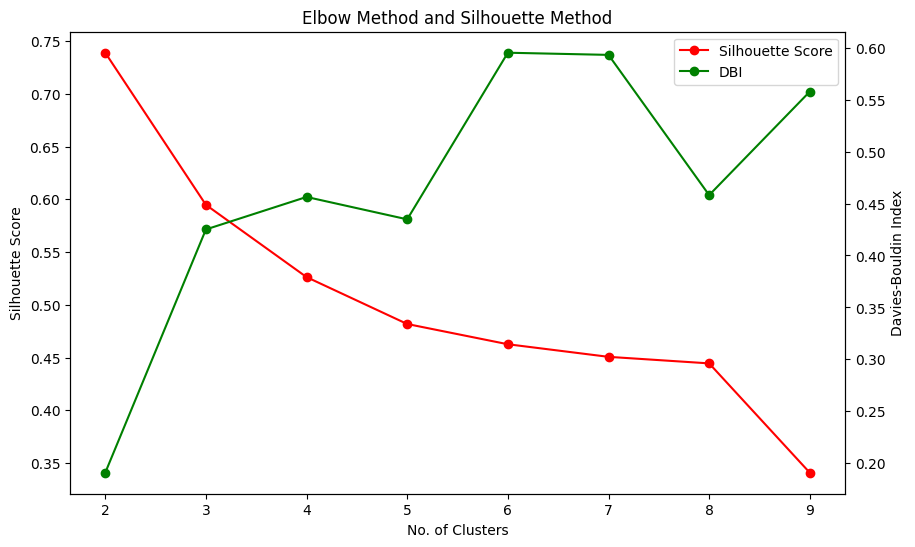

In [105]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Silhouette Score
line1, = ax1.plot(range(2, 10), silhoutte_scores, marker='o', label='Silhouette Score', color=color1)
ax1.set_xlabel('No. of Clusters')
ax1.set_ylabel('Silhouette Score')

# DBI
ax2 = ax1.twinx()
line2, = ax2.plot(range(2, 10), dbi_scores, marker='o', label='DBI', color=color2)
ax2.set_ylabel('Davies-Bouldin Index')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow Method and Silhouette Method')

plt.show()

- Silhouetter Score: Highest at k=2(strong and well separated clusters ~0.74), then declines from k=8.
- DBI: Lowest at k=2(best) spikes and stays high through most of the middle range, worst around k=6-7.

- Both metric strongly agrees at **k=2** for both KMeans and Hierarchial(Average Linkage) clustering algorithms.
- But due to **Average Linkage's tendency towards chaining** we should check is it actually two well separated groups or is it one dominant cluster plus a tiny, distant outlier cluster.

In [106]:
labels = fcluster(Z, t=2, criterion='maxclust')
print(np.unique(labels, return_counts=True))

(array([1, 2], dtype=int32), array([2215,    1], dtype=int64))


- There are **2215** customers in one cluster and **only one** in another cluster. That single point is so extreme/outlier from everyone else that Average Linkage split it off as separate cluster, this results in inflated silhouette score. The 0.71 silhouette wasen't evidence of two clean clusters, it was one extreme outlier distorting result. 

In [107]:
outlier_idx = np.where(labels == 2)[0]
X.iloc[outlier_idx]

,Age,Income,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
2233,49,10.944772,1.386294,1.732051,6


Remove and rerun by removing outlier

In [108]:
X_scaled_clean = np.delete(X_scaled, outlier_idx, axis=0)

In [109]:
silhoutte_scores = []
dbi_scores = []
Z = linkage(X_scaled_clean, method='average')
for k in range(2,10):
    labels = fcluster(Z, k, criterion='maxclust')
    silhoutte_scores.append(silhouette_score(X_scaled_clean, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled_clean, labels))

evaluation_metrics = pd.DataFrame({'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,Silhouetter Scores,DBI
2,0.595371,0.543095
3,0.526526,0.545664
4,0.482019,0.496429
5,0.462805,0.674901
6,0.450861,0.659209
7,0.444650,0.496936
8,0.340900,0.607334
9,0.339370,0.720437


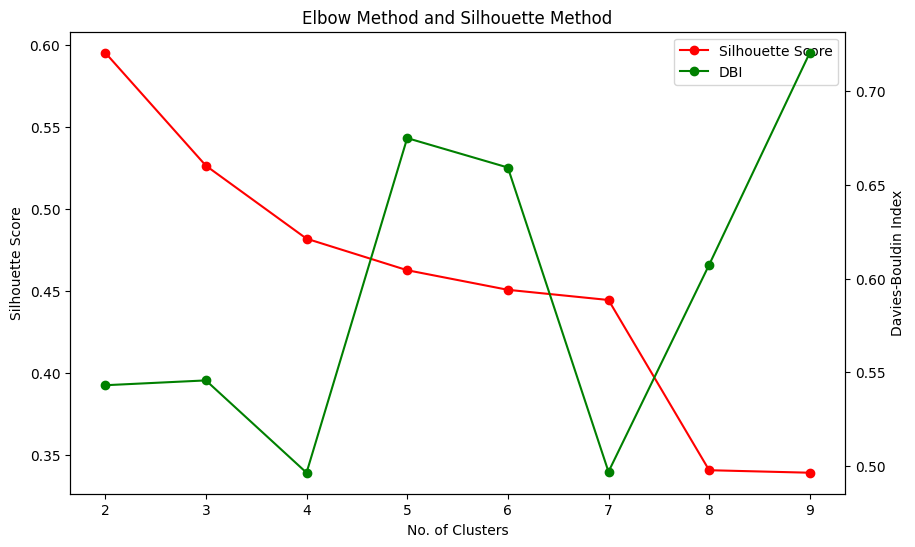

In [110]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Silhouette Score
line1, = ax1.plot(range(2, 10), silhoutte_scores, marker='o', label='Silhouette Score', color=color1)
ax1.set_xlabel('No. of Clusters')
ax1.set_ylabel('Silhouette Score')

# DBI
ax2 = ax1.twinx()
line2, = ax2.plot(range(2, 10), dbi_scores, marker='o', label='DBI', color=color2)
ax2.set_ylabel('Davies-Bouldin Index')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow Method and Silhouette Method')

plt.show() 

In [111]:
labels = fcluster(Z, t=4, criterion='maxclust')
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4], dtype=int32),
 array([   9,    3, 2202,    1], dtype=int64))

- Cluster assignments remain **inconsistent after applying improvements**, indicating that the **selected features should be re-evaluated** to ensure they provide stable and meaningful separation between customer segments.

### Using different set of features

In [112]:
## Dropping customers of age 100 and above. 
df.drop(list(df.index[df['Age'] >= 100]), axis=0, inplace=True)
df.shape

(2213, 37)

In [ ]:
df.index[df['Income'] == df['Income'].max()]

Index([2233], dtype='int64')

In [114]:
## Income of 666666 is likely data error
df.drop(2233, axis=0, inplace=True)

In [115]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
X = df[features].copy()

In [116]:
X['Age'].max(), X['Age'].min()

(86, 30)

- Previously, we observed that approximately **55% of customers belong to the 40–60 age range**. Based on this observation, we created a new **`AgeGroup`** feature and incorporated it into the clustering process to capture age-related differences in customer behavior.

In [117]:
bins = [18, 40 ,60, 140]
labels = ['18-39', '40-59', '60+']
X['AgeGroup'] = pd.cut(X['Age'], bins=bins, labels=labels)

In [118]:
X['AgeGroup'].value_counts()

AgeGroup
40-59    1179
60+       846
18-39     187
Name: count, dtype: int64

In [119]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  2212 non-null   int64   
 1   Income               2212 non-null   float64 
 2   Total_Spending       2212 non-null   int64   
 3   NumWebPurchases      2212 non-null   int64   
 4   NumCatalogPurchases  2212 non-null   int64   
 5   NumStorePurchases    2212 non-null   int64   
 6   AgeGroup             2212 non-null   category
dtypes: category(1), float64(1), int64(5)
memory usage: 123.3 KB


In [120]:
X['Income'] = X['Income'].astype('int64')

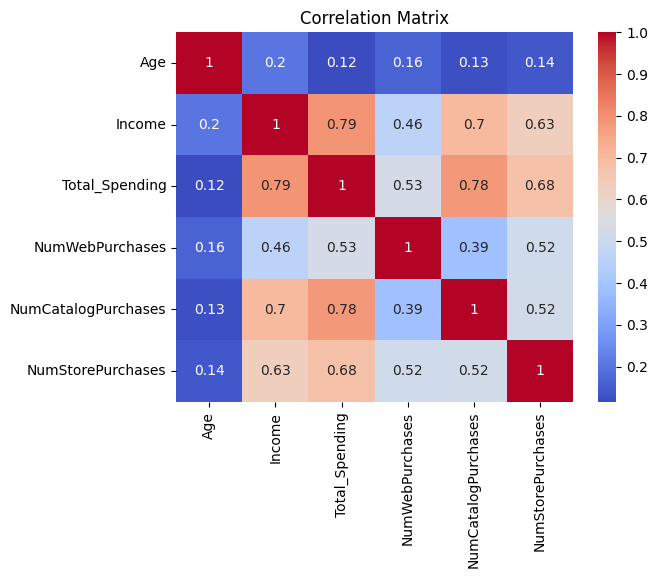

In [121]:
corr_matrix = X.select_dtypes(include='int').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- `Total_spending` has moderate correlation with `Income`, `NumWebPurchases`, `NumCatalogPurchases`.        

In [122]:
X.drop('Total_Spending', axis=1, inplace=True)

In [123]:
outlier_summary = {'features': [], 'lower_bound': [], 'upper_bound': [], 'outliers': [], 'outlier_perct': []}
for feature in X.select_dtypes(include='int'):
    Q1 = X[feature].quantile(0.25)
    Q3 = X[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - IQR*1.5
    upper_bound = Q3 + IQR*1.5

    outliers = X[(X[feature] > upper_bound) | (X[feature] < lower_bound)]

    outlier_perct = (len(outliers)/X.shape[0])*100

    outlier_summary['features'].append(feature)
    outlier_summary['lower_bound'].append(lower_bound)
    outlier_summary['upper_bound'].append(upper_bound)
    outlier_summary['outliers'].append(len(outliers))
    outlier_summary['outlier_perct'].append(outlier_perct)

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,features,lower_bound,upper_bound,outliers,outlier_perct
0,Age,22.00,94.00,0,0.000000
1,Income,-14646.75,118367.25,7,0.316456
2,NumWebPurchases,-4.00,12.00,3,0.135624
3,NumCatalogPurchases,-6.00,10.00,23,1.039783
4,NumStorePurchases,-4.50,15.50,0,0.000000


In [124]:
for feature in X.select_dtypes(include='int'):
    print(f"{feature}:{X[feature].skew() :.4f}")

Age:0.0934
Income:0.3480
NumWebPurchases:1.1953
NumCatalogPurchases:1.8815
NumStorePurchases:0.6997


In [125]:
X['Income'] = np.log1p(X['Income'])
X['NumCatalogPurchases'] = np.log1p(X['NumCatalogPurchases'])
X['NumStorePurchases'] = np.sqrt(X['NumStorePurchases'])
X['NumWebPurchases'] = np.log1p(X['NumWebPurchases'])

In [126]:
for feature in X.drop('AgeGroup', axis=1):
    print(f"{feature}:{X[feature].skew() :.4f}")

Age:0.0934
Income:-1.2491
NumWebPurchases:-0.2804
NumCatalogPurchases:0.1277
NumStorePurchases:0.1545


In [127]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

In [128]:
scalar = StandardScaler()
label = LabelEncoder()
X['AgeGroup'] = label.fit_transform(X['AgeGroup'])
X_scaled = scalar.fit_transform(X)

In [129]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

In [130]:
wcss = []
silhoutte_scores = []
dbi_scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, init='k-means++', verbose=False)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhoutte_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    dbi_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

In [131]:
evaluation_metrics = pd.DataFrame({'WCSS': wcss, 'Silhouetter Scores': silhoutte_scores, 'DBI': dbi_scores}, index=range(2,10))
evaluation_metrics

,WCSS,Silhouetter Scores,DBI
2,7962.225514,0.363679,1.119122
3,5888.890183,0.351486,1.060290
4,4832.866869,0.347650,1.061387
5,4420.557101,0.301851,1.188588
6,4055.211198,0.288769,1.340873
7,3752.210587,0.293461,1.275254
8,3468.078222,0.267828,1.364715
9,3240.227823,0.268444,1.324155


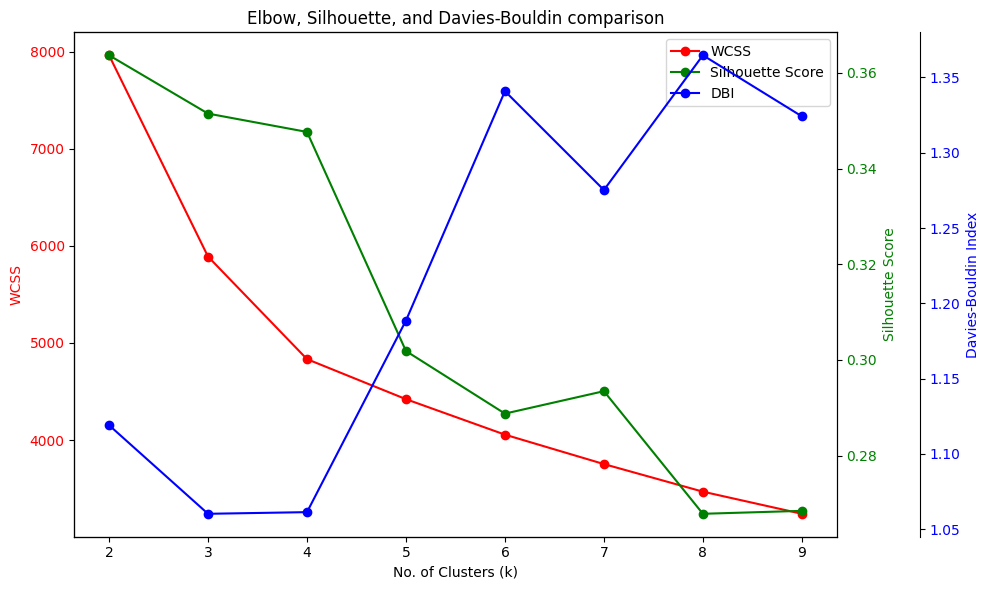

In [132]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# WCSS on primary y-axis
color1 = 'red'
ax1.set_xlabel('No. of Clusters (k)')
ax1.set_ylabel('WCSS', color=color1)
line1, = ax1.plot(range(2,10), wcss, marker='o', label='WCSS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Silhouette on second y-axis
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Silhouette Score', color=color2)
line2, = ax2.plot(range(2,10), silhoutte_scores, marker='o', label='Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# DBI on a third y-axis, offset outward
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'blue'
ax3.set_ylabel('Davies-Bouldin Index', color=color3)
line3, = ax3.plot(range(2,10), dbi_scores, marker='o', label='DBI', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

# Combined legend
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Elbow, Silhouette, and Davies-Bouldin comparison')
fig.tight_layout()
plt.show()

In [133]:
kmeans = KMeans(n_clusters=2)
df['Cluster_k2'] = kmeans.fit_predict(X_scaled)

In [134]:
df['Cluster_k2'].value_counts()

Cluster_k2
1    1274
0     938
Name: count, dtype: int64

In [135]:
kmeans = KMeans(n_clusters=3)
df['Cluster_k3'] = kmeans.fit_predict(X_scaled)

In [136]:
df['Cluster_k3'].value_counts()

Cluster_k3
1    870
2    679
0    663
Name: count, dtype: int64

In [137]:
bins = [18, 40 ,60, 100]
labels = ['18-39', '40-59', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [138]:
print('Cluster 0')
print(df[df['Cluster_k2'] == 0]['AgeGroup'].value_counts())
print()
print('Cluster 1')
print(df[df['Cluster_k2'] == 1]['AgeGroup'].value_counts())

Cluster 0
AgeGroup
40-59    613
60+      217
18-39    108
Name: count, dtype: int64

Cluster 1
AgeGroup
60+      629
40-59    566
18-39     79
Name: count, dtype: int64


In [139]:
print('Cluster 0')
print(df[df['Cluster_k3'] == 0]['AgeGroup'].value_counts())
print()
print('Cluster 1')
print(df[df['Cluster_k3'] == 1]['AgeGroup'].value_counts())
print()
print('Cluster 2')
print(df[df['Cluster_k3'] == 2]['AgeGroup'].value_counts())

Cluster 0
AgeGroup
60+      663
18-39      0
40-59      0
Name: count, dtype: int64

Cluster 1
AgeGroup
40-59    591
60+      183
18-39     96
Name: count, dtype: int64

Cluster 2
AgeGroup
40-59    588
18-39     91
60+        0
Name: count, dtype: int64


In [140]:
Cluster3_0 = df[df['Cluster_k3'] == 0]
Cluster3_1 = df[df['Cluster_k3'] == 1]
Cluster3_2 = df[df['Cluster_k3'] == 2]

In [141]:
def cluster_summary(Cluster, features):
    table = {'features': [], 'min': [], 'max': [], 'diff': [], 'mean': [], 'median': [], 'mode': []}
    for feature in features:
        table['features'].append(feature)
        table['min'].append(Cluster[feature].min())
        table['max'].append(Cluster[feature].max())
        table['diff'].append(Cluster[feature].max() - Cluster[feature].min())
        table['mean'].append(Cluster[feature].mean().round(2))
        table['median'].append(Cluster[feature].median())
        table['mode'].append(Cluster[feature].mode()[0])
    table_df = pd.DataFrame(table)
    return table_df


## Cluster: Older, Moderate-Income Customers

**Age:** This cluster has every customer 61 years old or above (min=61, max=133), making this cluster the "Older Customers" segment.
**Income:** Income is fairly symmetric (mean ≈ median: 63,399 vs. 63,361) ranging from 22,507 to 113,734 . a moderate, not extreme, income band for this group.

**Total Spending:** Also roughly symmetric (mean 885.59 vs. median 868) indicating no major residual skew within this cluster post-cleaning.

**Purchase Behavior:**
- **Web purchases:** Right-skewed, peaking at 4-5 purchases. Most customers made between 3 and 7 web purchases.
- **Catalog purchases:** Strongly right-skewed with mode at 1 purchase. Most customers made 1-4 catalog purchases. catalog is a secondary channel for this group.
- **Store purchases:** a primary group clustering around 4-6 store purchases, and a distinct secondary group around 10-12. This suggests two sub-behaviors within this cluster: moderate in-store shoppers and frequent in-store shoppers.

**Education:** This cluster is predominantly well-educated. Graduation is the single largest category (~315, roughly half the cluster), followed by PhD (~170) and Master (~130). Only a small minority fall into 2n Cycle (~45) or Basic (~negligible) education levels.

**Marital Status:** The majority of customers are in a committed relationship — Married (~235) and Together (~185) combined account for roughly 70% of this cluster. Single (~110) and Divorced (~75) make up smaller but meaningful shares, and Widow (~45) is notably present here.

In [142]:
cluster_summary(Cluster3_0, features)

,features,min,max,diff,mean,median,mode
0,Age,61.0,86.0,25.0,69.95,70.0,61.0
1,Income,22507.0,113734.0,91227.0,63317.55,63342.0,83844.0
2,Total_Spending,61.0,2440.0,2379.0,884.19,868.0,976.0
3,NumWebPurchases,1.0,27.0,26.0,5.39,5.0,4.0
4,NumCatalogPurchases,0.0,11.0,11.0,4.01,4.0,1.0
5,NumStorePurchases,0.0,13.0,13.0,7.33,7.0,5.0


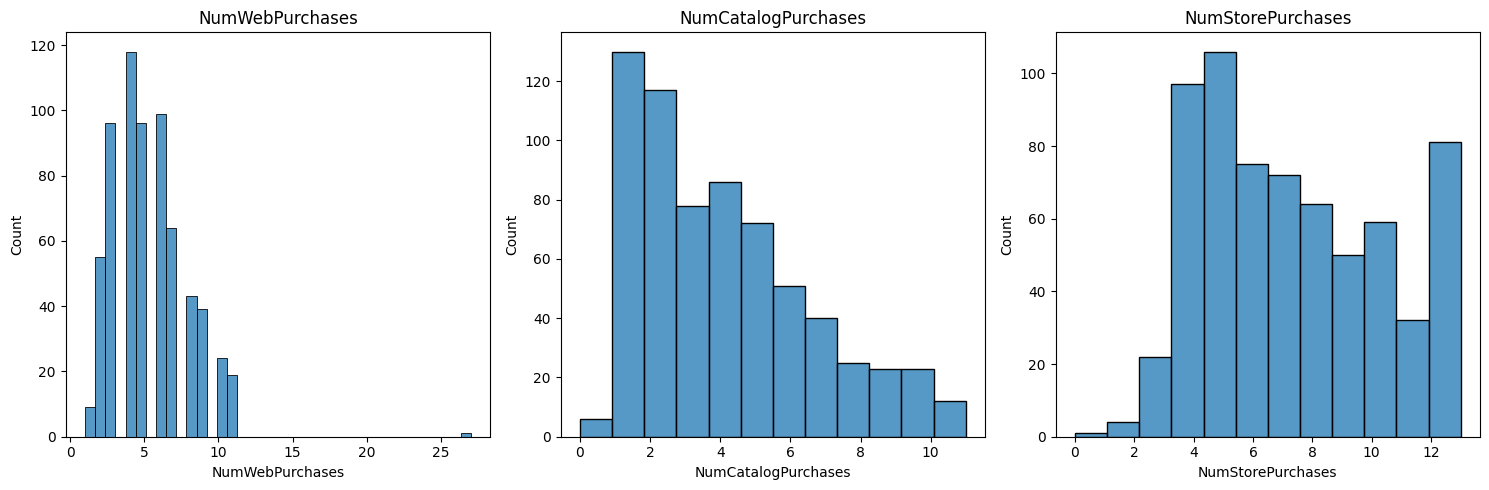

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_0[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

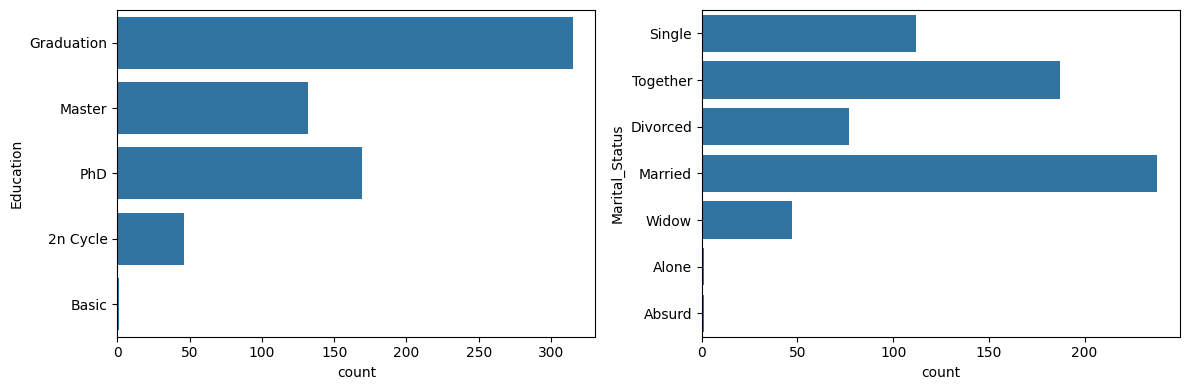

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_0['Education'], ax=ax[0])
sns.countplot(Cluster3_0['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()

## Cluster: Middle Age Customers

**Age:** Customers in this cluster range from 31 to 60. Median age is 51, half the cluster is 51 or younger and half are 51 or older with the oldest customers at 60. The KDE plot shows density concentrated toward 50-58, confirming this is a genuinely Middle aged skewed group.

**Income:** Ranges from 27,683 to 160,803. Mean (65,661.48) is slightly below median (66,373) a small skewness. Income is reasonably well-behaved for this cluster.

**Total Spending:** Bimodal distribution with primary peak around 400-500, secondary peak around 1,000-1,300 ndicating two distinct spending sub-behaviors within this cluster: a lower-spending group (~400-500) and a higher-spending group (~1,000-1,300).


**Purchase Behavior:**
- **Web Purchases:** Range 0-11. Most customers made 4-7 purchases, with 4 being the single most common value (mode). Very few made zero web purchases.
- **Catalog Purchases:** Range 1-28. Most customers made 1-4 purchases, with 2 being the most common value (mode). One isolated value near 27-28 stands apart from the rest of the distribution and is likely a residual outlier, not representative of typical behavior.
- **Store Purchases:** Range 1-13. Most customers made 5-8 purchases, with 6 being the most common value (mode)

**Education:** Graduation is the dominant category (372, well over half the cluster), followed by PhD (153) and Master (98). PhD holders outnumber Master's degree holders, consistent with the pattern seen in the other cluster. 2n Cycle (55) is a smaller minority, and Basic education is negligible (just 1 customer). This is a **well-educated** segment overall.

**Marital Status:** Married (277) is the largest group, followed by Together (168) and Single (152) these latter two are fairly close in size. Divorced (69) is a smaller minority and Widow (10) is minimal, consistent with this being a middle-aged (not older) segment. ('YOLO' and 'Absurd' are negligible data artifacts, not meaningful categories.)

In [143]:
cluster_summary(Cluster3_2, features)

,features,min,max,diff,mean,median,mode
0,Age,31.0,60.0,29.0,49.71,51.0,51.0
1,Income,27683.0,160803.0,133120.0,65661.48,66373.0,48432.0
2,Total_Spending,191.0,2525.0,2334.0,1015.56,969.0,401.0
3,NumWebPurchases,0.0,11.0,11.0,5.65,5.0,4.0
4,NumCatalogPurchases,1.0,28.0,27.0,4.18,4.0,2.0
5,NumStorePurchases,1.0,13.0,12.0,7.99,8.0,6.0


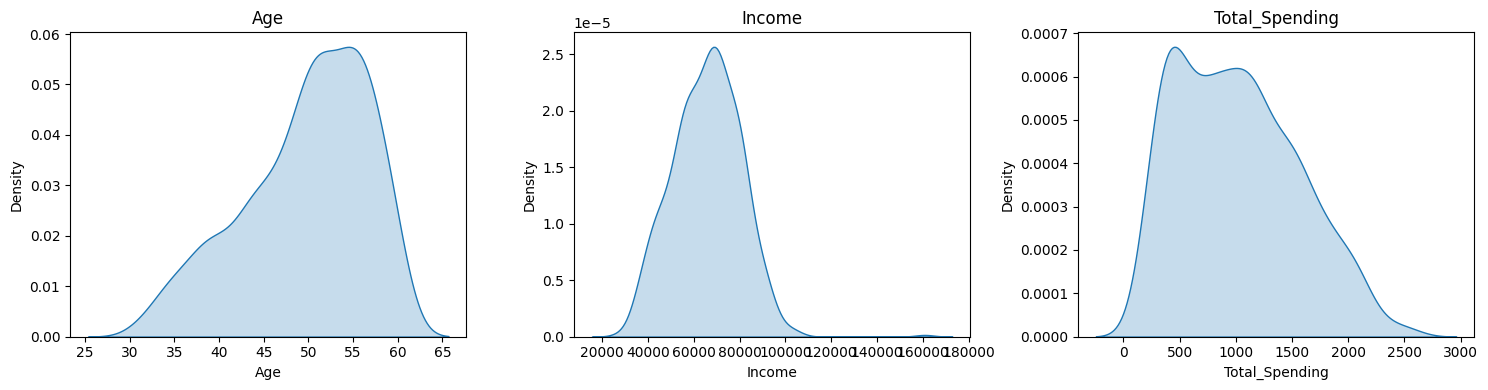

In [144]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
for i,feature in enumerate(['Age', 'Income', 'Total_Spending']):
    sns.kdeplot(Cluster3_2[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

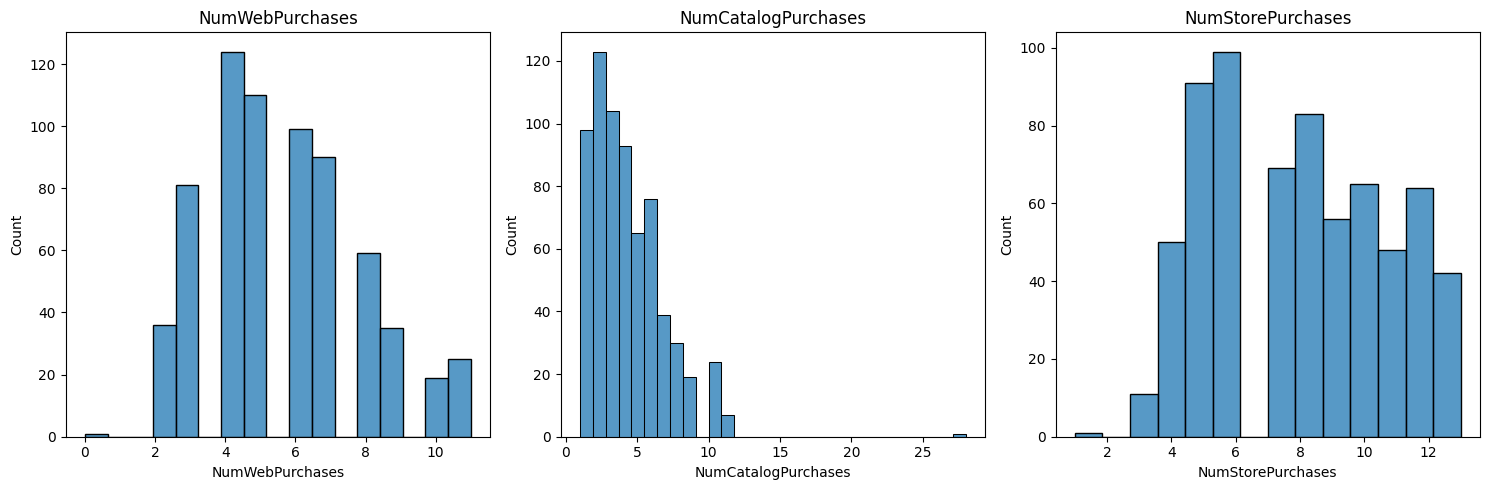

In [145]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_2[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

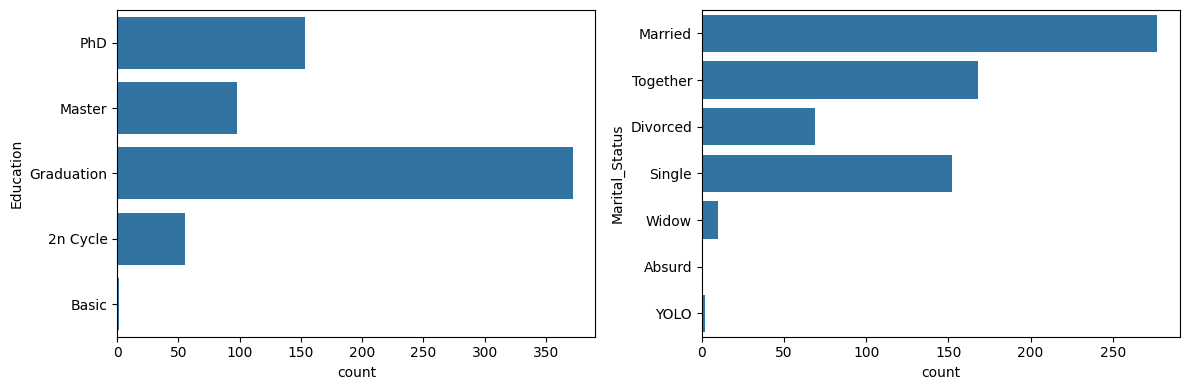

In [146]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_2['Education'], ax=ax[0])
sns.countplot(Cluster3_2['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()

## Cluster: Low-Income, Low engagement.
**Age:** Ranges from 30 to 80 ,notably wider than the other clusters (31-60). Mean (53.04) and median (52.5) are close, while mode (48) is little low indicating a mild right-skew. The KDE shows a concentration around 45-58.  

**Income:** Ranges from 1,730 to 162,397 the widest income range among the three clusters. Mean (32,608.29) and median (32,159.5) are both substantially lower than the other clusters (~65,000-66,000), making this clearly the **lowest-income segment**. The KDE shows a tight primary peak around 25,000-40,000, with a small peak near 150,000-160,000 likely a few residual high-income outliers.

**Total Spending:** Mean (77.58) is noticeably higher than median (55), indicating meaningful right-skew. Range is wide (5-1,730). The KDE shows a sharp peak near 0-100 with a long thin tail extending past 500. This is the **lowest-spending segment by a wide margin** compared to the other clusters' median spending (~870-1,015).

**Purchase Behavior:**

- **Web Purchases:** Range 0-25, heavily concentrated at the low end with mode and median both around 1-2. This group rarely shops online.
- **Catalog Purchases:** Range 0-28, highly concentrated at 0 (tallest bar by far, ~570), with most remaining customers at 1. Catalog is essentially unused by this segment.  
- **Store Purchases:** Range 0-6 — much narrower than the other clusters. Mode and median are both 3, clearly the dominant value (~460). This group makes modest but consistent store visits, well below the volume seen in the higher-spending clusters.

**Education:** Graduation is the dominant category (~430,over half), followed by PhD (~160) and Master (~135). 2n Cycle (~100) and Basic (~50) are smaller groups.

**Marital Status:** Married is the largest group (~340), followed by Together (~215) and Single (~205) these two are roughly of equal size, making this cluster more evenly split across relationship status than the older-customer cluster. Divorced (~85) and Widow (~20) are smaller minorities. ('Alone' is negligible.)

In [147]:
cluster_summary(Cluster3_1, features)

,features,min,max,diff,mean,median,mode
0,Age,30.0,80.0,50.0,53.04,52.5,48.0
1,Income,1730.0,162397.0,160667.0,32608.29,32159.5,7500.0
2,Total_Spending,5.0,1730.0,1725.0,77.58,55.0,46.0
3,NumWebPurchases,0.0,25.0,25.0,1.88,2.0,1.0
4,NumCatalogPurchases,0.0,28.0,28.0,0.48,0.0,0.0
5,NumStorePurchases,0.0,6.0,6.0,2.94,3.0,3.0


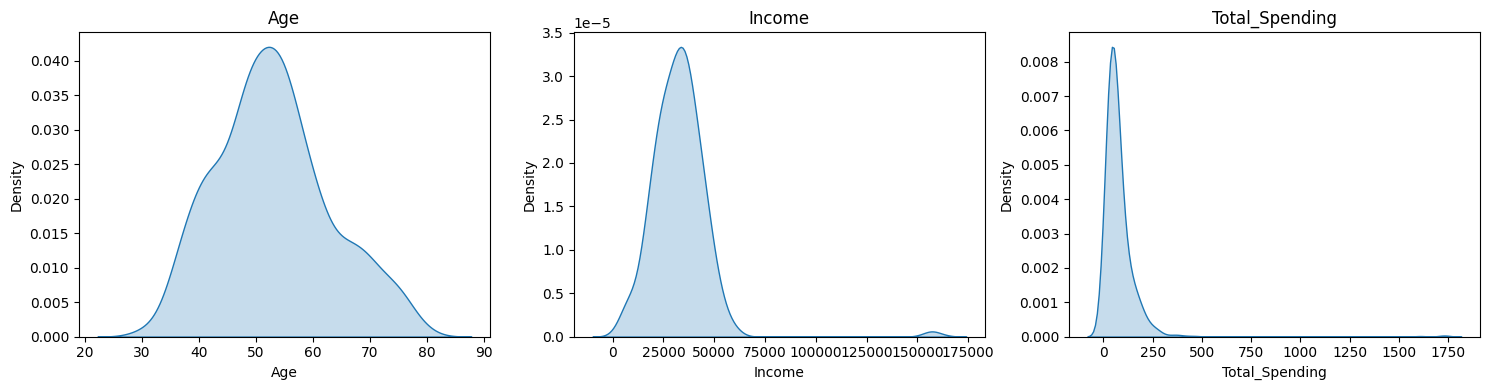

In [148]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
for i,feature in enumerate(['Age', 'Income', 'Total_Spending']):
    sns.kdeplot(Cluster3_1[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

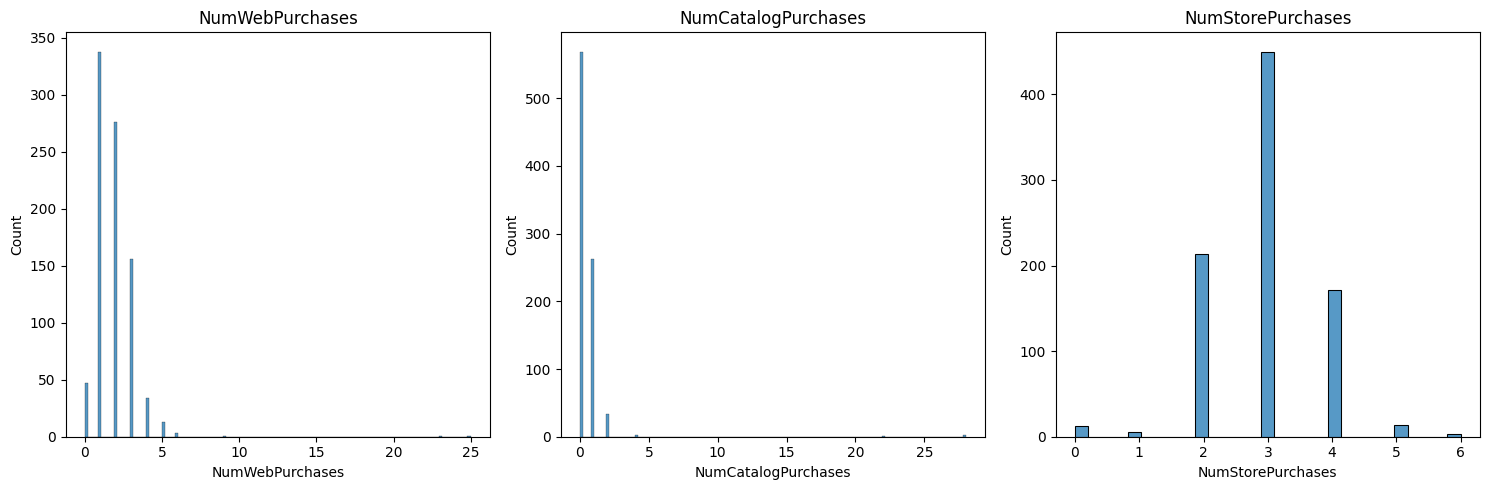

In [149]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i,feature in enumerate(['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']):
    sns.histplot(Cluster3_1[feature], ax=ax[i])
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

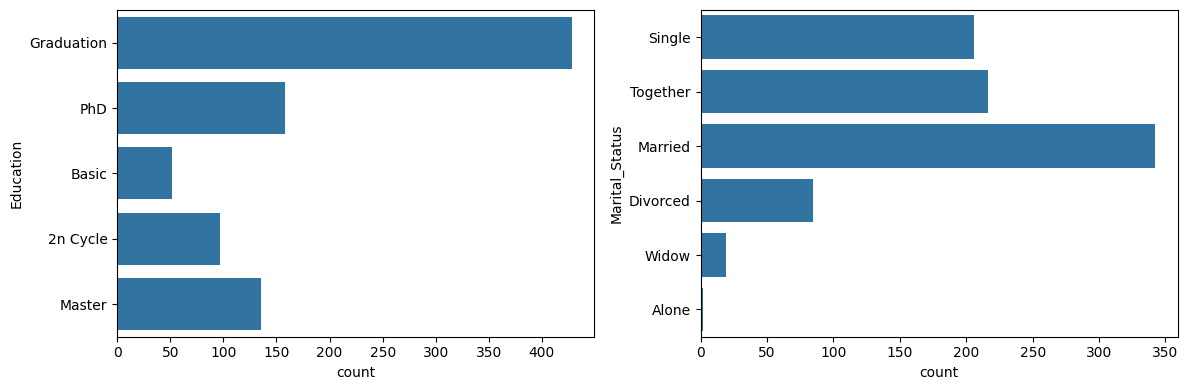

In [150]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.countplot(Cluster3_1['Education'], ax=ax[0])
sns.countplot(Cluster3_1['Marital_Status'], ax=ax[1])
plt.tight_layout()
plt.show()